In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mtb
import seaborn as sns

In [4]:
df=pd.read_csv(r'C:\ML_PROJECT\financial_regression.csv')

In [5]:
df.head()

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


In [6]:
df.shape

(3904, 47)

In [7]:
df.isnull().sum()

date                     0
sp500 open             185
sp500 high             185
sp500 low              185
sp500 close            185
sp500 volume           185
sp500 high-low         185
nasdaq open            185
nasdaq high            185
nasdaq low             185
nasdaq close           185
nasdaq volume          185
nasdaq high-low        185
us_rates_%            3728
CPI                   3728
usd_chf                210
eur_usd                210
GDP                   3847
silver open            185
silver high            185
silver low             185
silver close           185
silver volume          185
silver high-low        185
oil open               185
oil high               185
oil low                185
oil close              185
oil volume             185
oil high-low           185
platinum open          185
platinum high          185
platinum low           185
platinum close         185
platinum volume        185
platinum high-low      185
palladium open         185
p

In [8]:
high_missing = df.columns[df.isnull().mean() > 0.4]
df = df.drop(columns=high_missing)


In [9]:
df

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.1400,114.4200,114.93,115646960.0,0.7200,46.26,46.520,46.2200,...,45.0200,43.8600,44.84,364528.0,1.1600,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.8400,113.2000,113.64,212252769.0,1.6400,46.46,46.550,45.6500,...,45.7600,44.4000,45.76,442210.0,1.3600,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.1300,113.5900,115.06,138671890.0,1.5400,45.96,46.640,45.9500,...,47.0800,45.7000,46.94,629150.0,1.3800,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.4500,112.9800,113.89,216330645.0,1.4700,46.27,46.604,45.4300,...,47.3100,45.1700,47.05,643198.0,2.1400,109.97,110.05,108.46,108.94,17534231.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3899,2024-10-17,585.91,586.1200,582.1600,582.35,34393714.0,3.9600,496.44,496.490,491.1901,...,96.0259,94.5400,95.68,52414.0,1.4859,247.75,249.06,247.62,248.63,5176170.0
3900,2024-10-18,584.07,585.3900,582.5800,584.59,37416801.0,2.8100,494.06,495.570,493.3000,...,99.6600,97.2700,99.46,205027.0,2.3900,250.00,251.37,249.90,251.27,7833614.0
3901,2024-10-21,583.85,584.8500,580.6001,583.63,36439010.0,4.2499,493.25,496.230,491.3100,...,98.3500,95.8900,97.35,227394.0,2.4600,252.74,253.14,250.73,251.22,9258590.0
3902,2024-10-22,581.05,584.5000,580.3800,583.32,34183835.0,4.1200,492.73,497.445,491.9700,...,99.5899,97.9600,99.41,136431.0,1.6299,253.06,253.94,252.52,253.93,5756321.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 44 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3904 non-null   object 
 1   sp500 open          3719 non-null   float64
 2   sp500 high          3719 non-null   float64
 3   sp500 low           3719 non-null   float64
 4   sp500 close         3719 non-null   float64
 5   sp500 volume        3719 non-null   float64
 6   sp500 high-low      3719 non-null   float64
 7   nasdaq open         3719 non-null   float64
 8   nasdaq high         3719 non-null   float64
 9   nasdaq low          3719 non-null   float64
 10  nasdaq close        3719 non-null   float64
 11  nasdaq volume       3719 non-null   float64
 12  nasdaq high-low     3719 non-null   float64
 13  usd_chf             3694 non-null   float64
 14  eur_usd             3694 non-null   float64
 15  silver open         3719 non-null   float64
 16  silver

In [11]:
df['date'] = pd.to_datetime(df['date'])
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day

df=df.drop(columns=['date'])

In [12]:
df

,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,nasdaq close,...,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume,Year,Month,Day
0,114.49,115.1400,114.4200,114.93,115646960.0,0.7200,46.26,46.520,46.2200,46.39,...,364528.0,1.1600,111.51,112.37,110.79,112.03,18305238.0,2010,1,14
1,114.73,114.8400,113.2000,113.64,212252769.0,1.6400,46.46,46.550,45.6500,45.85,...,442210.0,1.3600,111.35,112.01,110.38,110.86,18000724.0,2010,1,15
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010,1,18
3,113.62,115.1300,113.5900,115.06,138671890.0,1.5400,45.96,46.640,45.9500,46.59,...,629150.0,1.3800,110.95,111.75,110.83,111.52,10467927.0,2010,1,19
4,114.28,114.4500,112.9800,113.89,216330645.0,1.4700,46.27,46.604,45.4300,45.92,...,643198.0,2.1400,109.97,110.05,108.46,108.94,17534231.0,2010,1,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3899,585.91,586.1200,582.1600,582.35,34393714.0,3.9600,496.44,496.490,491.1901,491.25,...,52414.0,1.4859,247.75,249.06,247.62,248.63,5176170.0,2024,10,17
3900,584.07,585.3900,582.5800,584.59,37416801.0,2.8100,494.06,495.570,493.3000,494.47,...,205027.0,2.3900,250.00,251.37,249.90,251.27,7833614.0,2024,10,18
3901,583.85,584.8500,580.6001,583.63,36439010.0,4.2499,493.25,496.230,491.3100,495.42,...,227394.0,2.4600,252.74,253.14,250.73,251.22,9258590.0,2024,10,21
3902,581.05,584.5000,580.3800,583.32,34183835.0,4.1200,492.73,497.445,491.9700,495.96,...,136431.0,1.6299,253.06,253.94,252.52,253.93,5756321.0,2024,10,22


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sp500 open          3719 non-null   float64
 1   sp500 high          3719 non-null   float64
 2   sp500 low           3719 non-null   float64
 3   sp500 close         3719 non-null   float64
 4   sp500 volume        3719 non-null   float64
 5   sp500 high-low      3719 non-null   float64
 6   nasdaq open         3719 non-null   float64
 7   nasdaq high         3719 non-null   float64
 8   nasdaq low          3719 non-null   float64
 9   nasdaq close        3719 non-null   float64
 10  nasdaq volume       3719 non-null   float64
 11  nasdaq high-low     3719 non-null   float64
 12  usd_chf             3694 non-null   float64
 13  eur_usd             3694 non-null   float64
 14  silver open         3719 non-null   float64
 15  silver high         3719 non-null   float64
 16  silver

In [14]:
df=df.fillna(df.mean(numeric_only=True))

In [15]:
df.isnull().sum().sum()


np.int64(0)

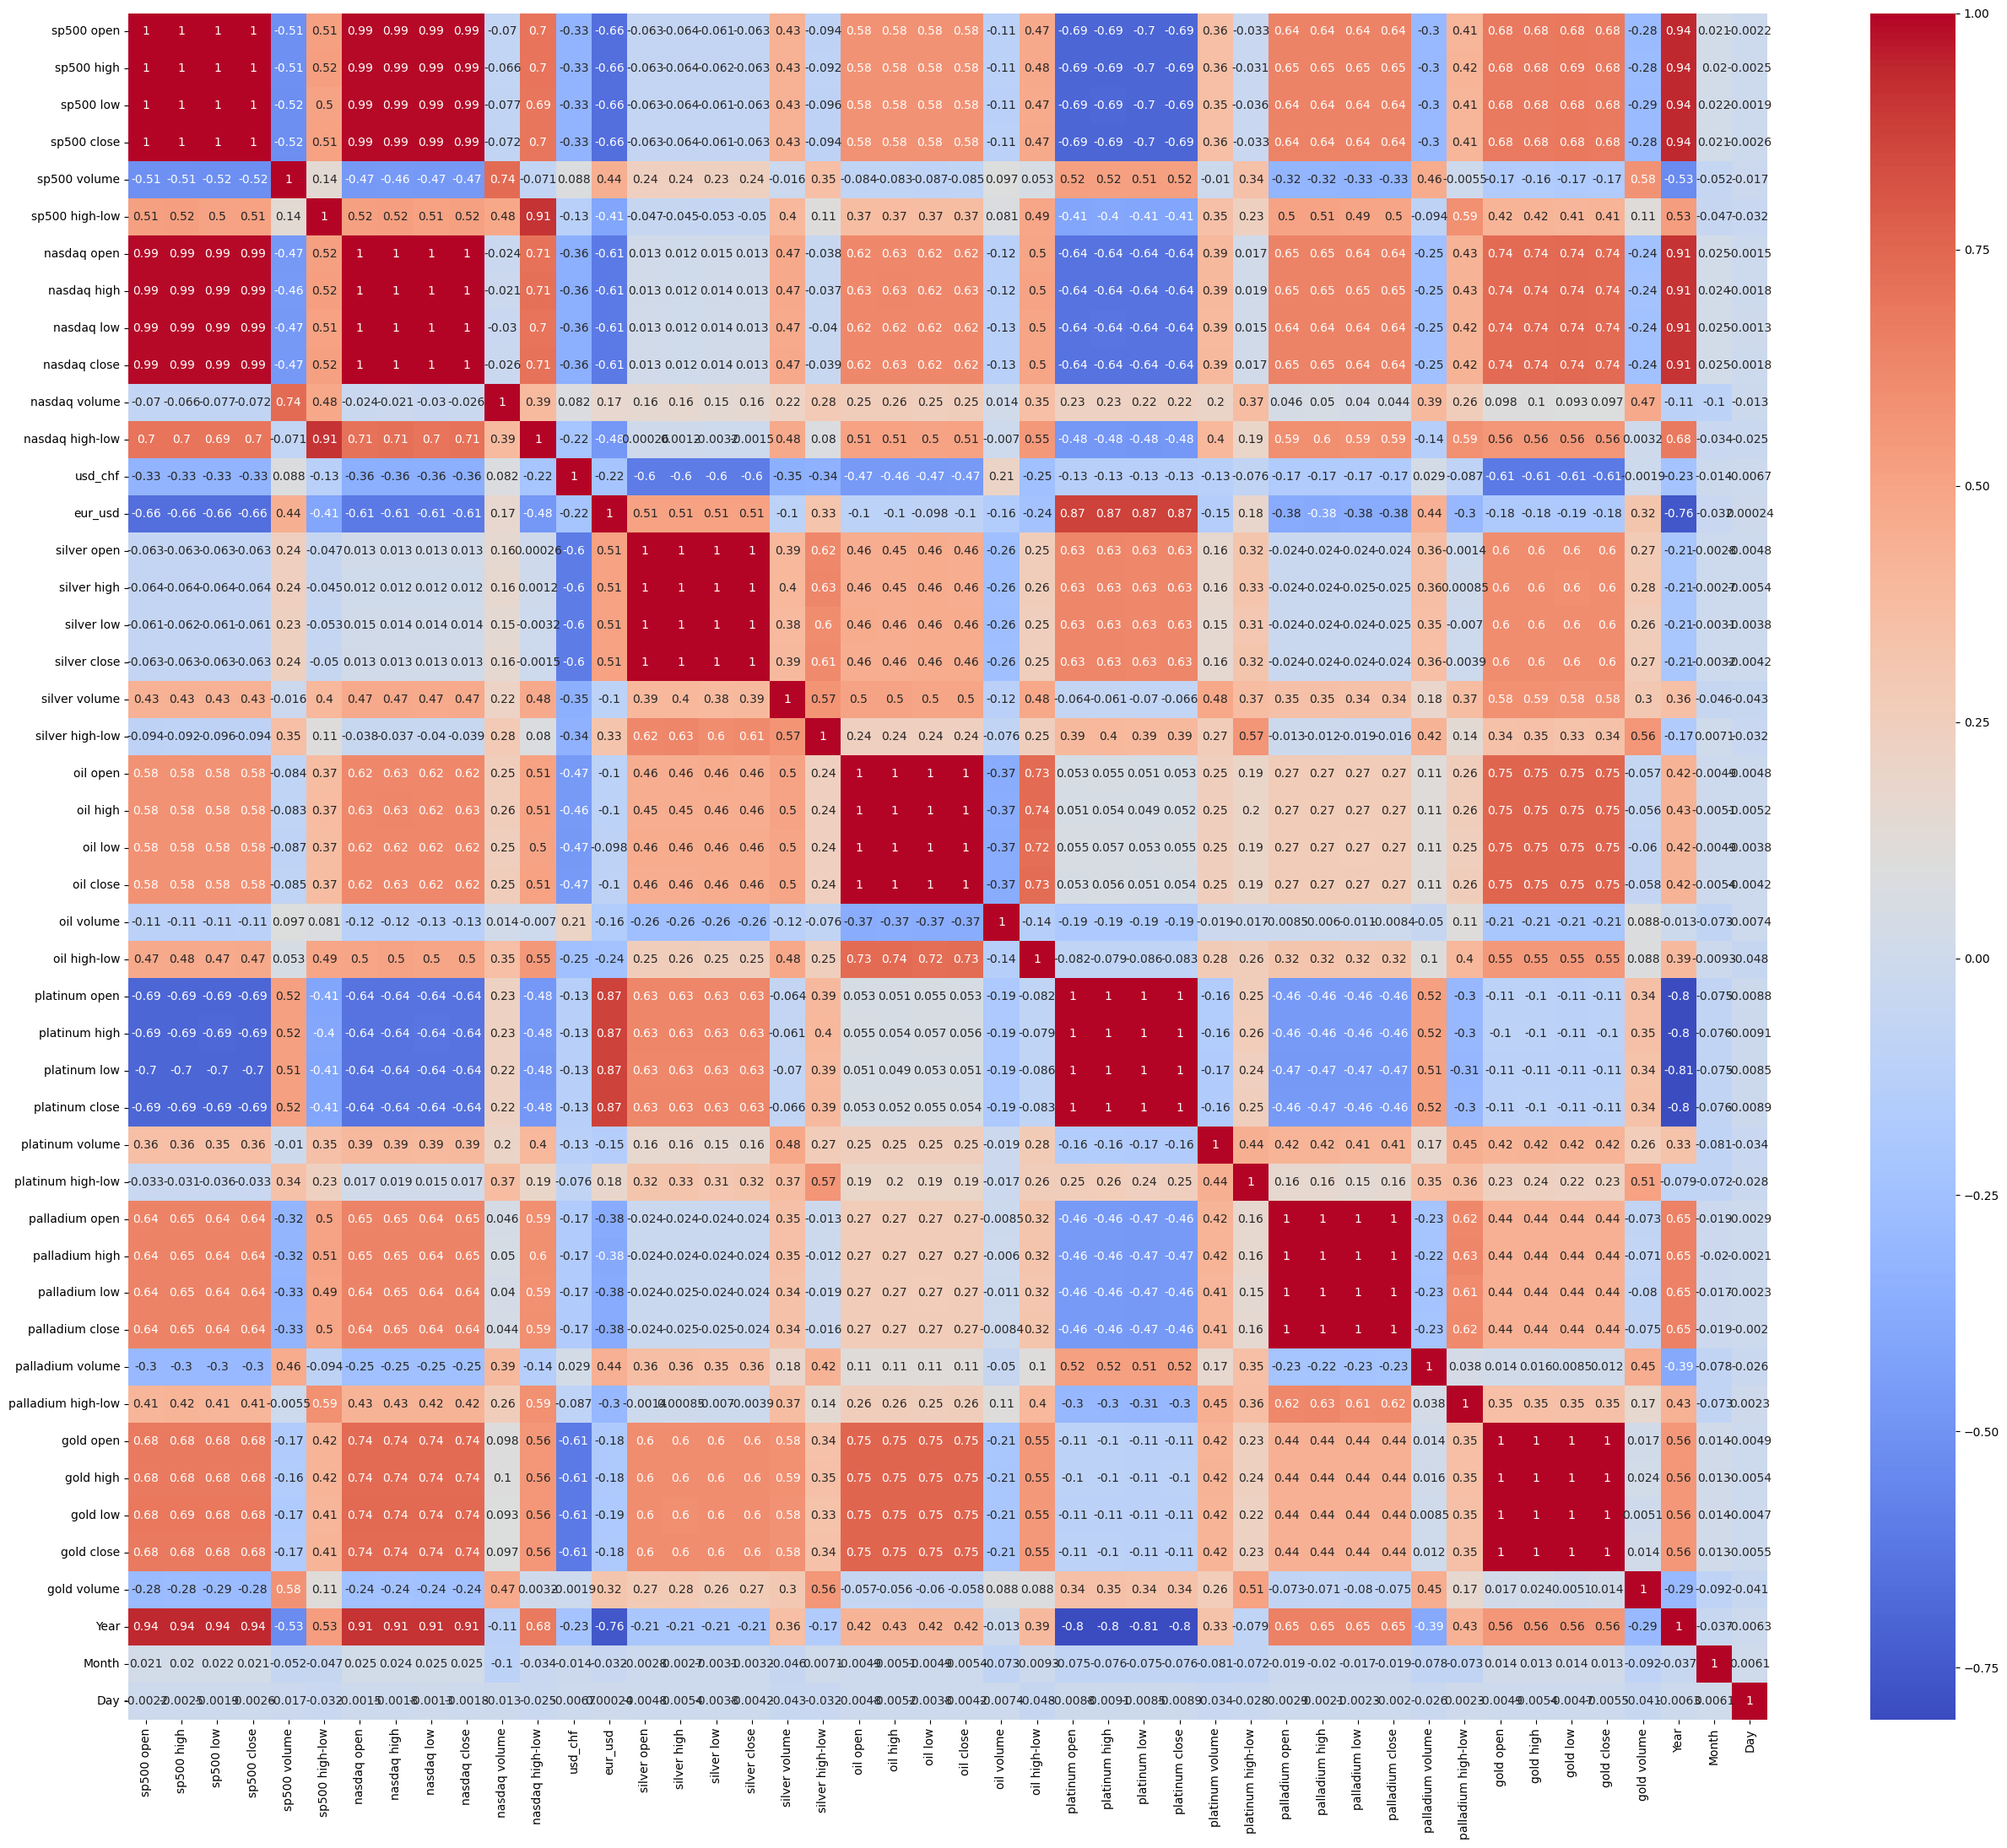

In [16]:
mtb.figure(figsize=(26,22))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)            
mtb.xticks(rotation=90)
mtb.yticks(rotation=0)
mtb.tight_layout()
mtb.show()


In [17]:
df

,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,nasdaq close,...,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume,Year,Month,Day
0,114.490000,115.140000,114.420000,114.930000,1.156470e+08,0.72000,46.260000,46.520000,46.22000,46.390000,...,364528.000000,1.160000,111.510000,112.370000,110.790000,112.030000,1.830524e+07,2010,1,14
1,114.730000,114.840000,113.200000,113.640000,2.122528e+08,1.64000,46.460000,46.550000,45.65000,45.850000,...,442210.000000,1.360000,111.350000,112.010000,110.380000,110.860000,1.800072e+07,2010,1,15
2,268.732724,270.179765,267.157446,268.779352,1.124206e+08,3.02232,181.394495,182.689784,179.98249,181.431795,...,71695.557139,2.252611,145.454975,146.101477,144.761329,145.453861,9.658138e+06,2010,1,18
3,113.620000,115.130000,113.590000,115.060000,1.386719e+08,1.54000,45.960000,46.640000,45.95000,46.590000,...,629150.000000,1.380000,110.950000,111.750000,110.830000,111.520000,1.046793e+07,2010,1,19
4,114.280000,114.450000,112.980000,113.890000,2.163306e+08,1.47000,46.270000,46.604000,45.43000,45.920000,...,643198.000000,2.140000,109.970000,110.050000,108.460000,108.940000,1.753423e+07,2010,1,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3899,585.910000,586.120000,582.160000,582.350000,3.439371e+07,3.96000,496.440000,496.490000,491.19010,491.250000,...,52414.000000,1.485900,247.750000,249.060000,247.620000,248.630000,5.176170e+06,2024,10,17
3900,584.070000,585.390000,582.580000,584.590000,3.741680e+07,2.81000,494.060000,495.570000,493.30000,494.470000,...,205027.000000,2.390000,250.000000,251.370000,249.900000,251.270000,7.833614e+06,2024,10,18
3901,583.850000,584.850000,580.600100,583.630000,3.643901e+07,4.24990,493.250000,496.230000,491.31000,495.420000,...,227394.000000,2.460000,252.740000,253.140000,250.730000,251.220000,9.258590e+06,2024,10,21
3902,581.050000,584.500000,580.380000,583.320000,3.418384e+07,4.12000,492.730000,497.445000,491.97000,495.960000,...,136431.000000,1.629900,253.060000,253.940000,252.520000,253.930000,5.756321e+06,2024,10,22


In [18]:
X = df.drop('gold close',axis=1)
y = df['gold close']


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    
)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred = model.predict(X_test)


In [23]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mse)
print(r2)


0.06644581962014096
0.9999189712917343


In [24]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [25]:
y_pred = knn.predict(X_test)


In [26]:
from sklearn.metrics import mean_absolute_error, r2_score

knn_mae = mean_absolute_error(y_test, y_pred)
knn_r2 = r2_score(y_test, y_pred)

print("KNN_mae:",knn_mae)
print("KNN_R2:", knn_r2)


KNN_mae: 1.7101309603072994
KNN_R2: 0.9923614324570369


In [27]:
from sklearn.svm import SVR
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train, y_train)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [28]:
y_pred_svr = svr_model.predict(X_test)


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_svr)
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_svr)

print("SVR MAE :", mae)
print("SVR MSE :", mse)
print("SVR RMSE:", rmse)
print("SVR R2 Score:", r2)


SVR MAE : 1.8658081875492487
SVR MSE : 16.982186070136315
SVR RMSE: 4.120944803092649
SVR R2 Score: 0.979290727262338


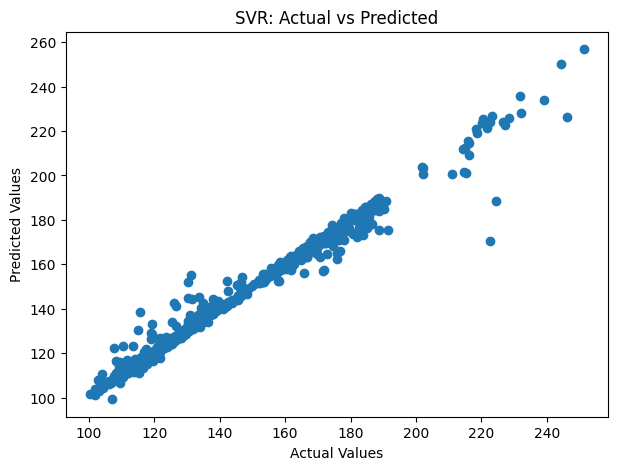

In [31]:
mtb.figure(figsize=(7,5))
mtb.scatter(y_test, y_pred_svr)
mtb.xlabel("Actual Values")
mtb.ylabel("Predicted Values")
mtb.title("SVR: Actual vs Predicted")
mtb.show()
